# Fine-tuning a ResNet Model for Dog Breed Classification
 #### A final academic project in partial fulfillment of the requirements for the course CSELEC2C: Machine Learning
 Prepared by Raul Sebastien B. Baldemoro, Gilberto Miguel N. Buot, Jan Vincent G. Elleazar, Andrei John R. Gonzalez, Dlanor Haniel, Carl Jacob F. Mateo, and Laurence Gabriel T. Macatangay
 <br> Department of Computer Science, College of Information and Computing Sciences, University of Santo Tomas, City of Manila, Philippines
 <br><br>
 ***

## Overview of the Final Academic Project

Our primary objective is to **fine-tune a pre-trained neural network and use it on a task that we want to work on**. We choose to fine-tune the ResNet-50 v1.5, a ResNet model that was first introduced in the paper  *Deep Residual Learning for Image Recognition* by He et al. in 2015. As for the task, we will train the ResNet model for dog breed classification using the Standford Dogs Dataset.
<br><br>
***

## Libraries
Import the necessary libraries

In [32]:
# Core Python and File Handling
import os
import random
import zipfile
from pathlib import Path
from collections import Counter

# Data Handling
import pandas as pd
import numpy as np

# Image and XML Parsing
from PIL import Image
import xml.etree.ElementTree as ET

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Splitting
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ResNet Model
from transformers import TFResNetForImageClassification

## Working on Dataset
This section presents the initial works on the dataset:
- Data Inspection
- Exploratory Data Analysis
- Data Extraction
- Data Preprocessing
- Data Load and Split




### Data Inspection
We will verify the number of images as according to the dataset source, there are 120 categories and 20580 images.

In [2]:
# Extraction
archive = "archive.zip"

with zipfile.ZipFile(archive, 'r') as zip_ref:
    zip_ref.extractall()

print("Extract Success")
print(os.listdir())

Extract Success
['ML_Final_Academic_Project.ipynb', '.DS_Store', 'images', 'annotations', 'archive.zip']


In [3]:
#Confirm if all images are .jpg (not .jpeg or .png)
image_dir = Path("archive/Images")
non_jpg_files = []

for file in image_dir.rglob("*"):
    if file.is_file():
        ext = file.suffix.lower().strip()
        if ext not in [".jpg"]:
            non_jpg_files.append(file)

if non_jpg_files:
    print(f"Found {len(non_jpg_files)} non-JPG image files:")
    for f in non_jpg_files[:10]:  # show only first 10
        print("-", f)
else:
    print("All images are .jpg")

All images are .jpg


In [9]:
#Verification of Data (120 Classifications and 20580 Images)

image_dir = Path("archive/Images")
image_extensions = ['.jpg']

# Total image count
total_images = sum(1 for f in image_dir.rglob('*') if f.suffix.lower() in image_extensions)

# Total breed classifications (directories)
breed_folders = [f for f in image_dir.iterdir() if f.is_dir()]
total_breeds = len(breed_folders)

# Output
print(f"📸 Total images: {total_images}")
print(f"🐶 Total breed classes: {total_breeds}")

📸 Total images: 20580
🐶 Total breed classes: 120


### Exploratory Data Analysis
We will use visualization techniques to explore the dataset and its statistics.

/var/folders/vs/zcjd1wds7_78_tmdl741y03m0000gn/T/ipykernel_10242/3809656863.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


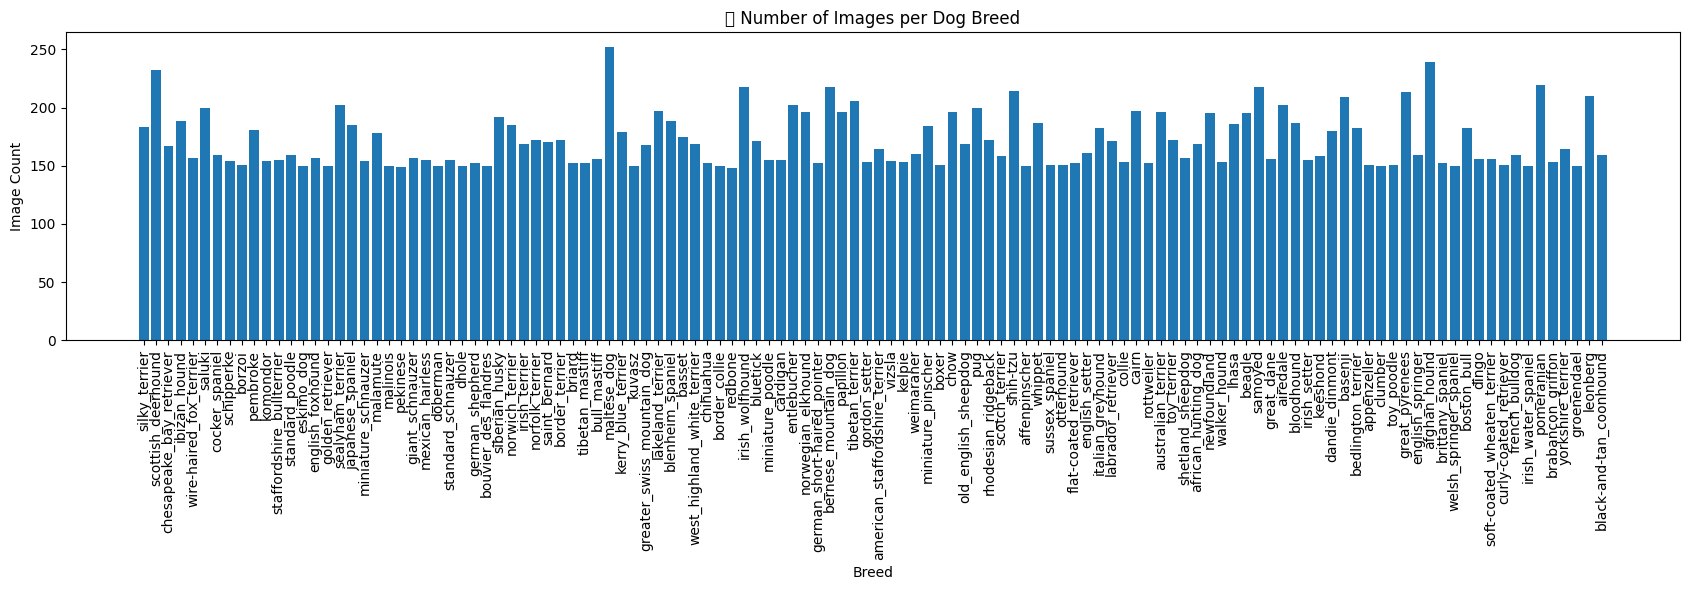

In [10]:
#Determine if the dataset is balanced
image_dir = Path("archive/Images")

class_counts = Counter()
for class_folder in image_dir.iterdir():
    if class_folder.is_dir():
        raw_name = class_folder.name
        clean_name = raw_name.split("-", 1)[-1].lower()
        class_counts[clean_name] = len(list(class_folder.glob("*.jpg")))

# Plot
plt.figure(figsize=(17, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("📊 Number of Images per Dog Breed")
plt.xlabel("Breed")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

In [11]:
#Most common image dimensions
image_shapes = []

for class_folder in image_dir.iterdir():
    for image_path in class_folder.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_shapes.append(img.size)  # (width, height)

# 10 most common dimensions
from collections import Counter
common_dims = Counter(image_shapes).most_common(10)
print("Most common image dimensions:")
for dim, count in common_dims:
    print(f"{dim}: {count} images")

Most common image dimensions:
(500, 375): 5301 images
(500, 333): 2098 images
(375, 500): 1225 images
(333, 500): 706 images
(500, 334): 356 images
(500, 332): 298 images
(334, 500): 138 images
(500, 400): 132 images
(500, 357): 117 images
(400, 300): 117 images


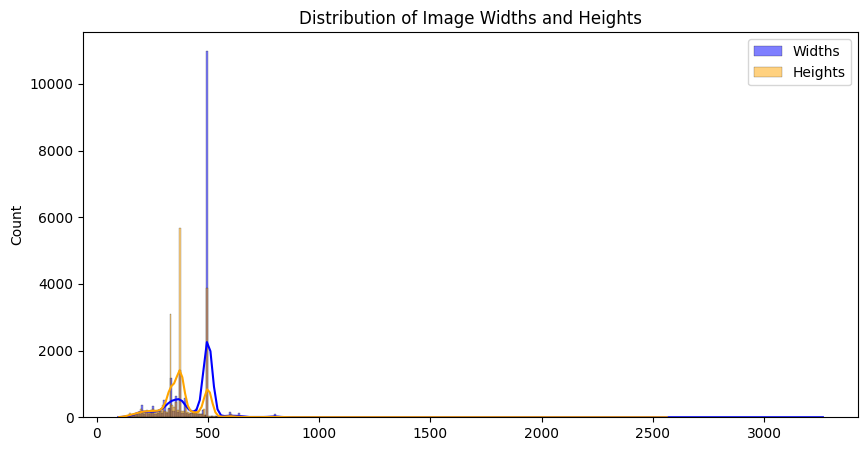

In [12]:
#Width and Height Trend
widths = [w for w, h in image_shapes]
heights = [h for w, h in image_shapes]

plt.figure(figsize=(10, 5))
sns.histplot(widths, color='blue', label='Widths', kde=True)
sns.histplot(heights, color='orange', label='Heights', kde=True)
plt.legend()
plt.title("Distribution of Image Widths and Heights")
plt.show()

### Data Extraction
We will extract the dataset to a data frame in preparation for data preprocessing, splitting, and loading

In [13]:
#Data Extraction and Data Frame
annotation_dir = Path("archive/Annotation")
image_dir = Path("archive/Images")

# Add .xml extension if missing
for breed_folder in annotation_dir.iterdir():
    if breed_folder.is_dir():
        for file in breed_folder.iterdir():
            if file.is_file() and file.suffix == '':
                file.rename(file.with_name(file.name + ".xml"))

# Build WordNet ID to folder name map
folder_map = {
    folder.name.lower().split("-")[0]: folder.name
    for folder in image_dir.iterdir()
    if folder.is_dir()
}

records = []

# Parse XML and collect records
for xml_file in annotation_dir.rglob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename_tag = root.find("filename")
    if filename_tag is not None and filename_tag.text.strip() == "%s":
        filename_tag.text = xml_file.stem + ".jpg"
        tree.write(xml_file)

    filename = filename_tag.text
    wordnet_id = filename.split("_")[0].lower()

    folder_name = folder_map.get(wordnet_id)
    if folder_name is None:
        print(f"No folder found for ID: {wordnet_id}")
        continue

    if not filename.lower().endswith(".jpg"):
        filename += ".jpg"

    image_path = image_dir / folder_name / filename

    # Remove WordNet ID and keep underscores
    breed_clean = folder_name[len(wordnet_id)+1:]

    records.append((str(image_path), breed_clean))

# Create initial DataFrame
df = pd.DataFrame(records, columns=["image_path", "breed"])
print(f"Records collected: {len(df)}")


Records collected: 20580


In [14]:
#Label Encoding
# Map each breed to a unique integer label
breed_to_label = {breed: i for i, breed in enumerate(sorted(df["breed"].unique()))}
df["label"] = df["breed"].map(breed_to_label)

# Preview
print("Breed to Label Mapping:")
for breed, label in list(breed_to_label.items())[:10]:
    print(f"{label}: {breed}")


Breed to Label Mapping:
0: Afghan_hound
1: African_hunting_dog
2: Airedale
3: American_Staffordshire_terrier
4: Appenzeller
5: Australian_terrier
6: Bedlington_terrier
7: Bernese_mountain_dog
8: Blenheim_spaniel
9: Border_collie


### Data Preprocessing
We will use different preprocessing methods for the images

In [15]:
# Target size for ResNet input (224x224 recommended)
img_size = (224, 224)

# Preprocessing: normalization (rescale pixel values to [0, 1])
datagen = ImageDataGenerator(rescale=1./255)

### Data Splitting and Loading
Finally, we will split the data into training and validation sets, and then load it into the ResNet model

In [16]:
# Data splitting
# 80% training, 20% validation split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# Convert labels to string format for ImageDataGenerator
train_df["label_str"] = train_df["label"].astype(str)
val_df["label_str"] = val_df["label"].astype(str)

In [17]:
# Data Loading
# Training generator
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label_str",
    target_size=img_size,
    batch_size=32,
    class_mode="sparse",
    shuffle=True
)

# Validation generator
val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label_str",
    target_size=img_size,
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)

Found 16464 validated image filenames belonging to 120 classes.
Found 4116 validated image filenames belonging to 120 classes.


***
## Initial ResNet Model Run
This section presents the performance and the result of the ResNet model **before** fine-tuning.

In [34]:
# Get the number of classes from the training generator
num_classes = len(train_gen.class_indices)
print(f"Number of output classes: {num_classes}")

# Load the ResNet-50 v1.5 model. We will train the last layer.
model = TFResNetForImageClassification.from_pretrained(
    "microsoft/resnet-50",
    num_labels=num_classes, # Set the number of output labels to our classes
    ignore_mismatched_sizes=True # Ignore if the pre-trained head doesn't match
)

# Compile the model
# We will use Adam optimizer and SparseCategoricalCrossentropy loss
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Train the model
epochs = 5  # Define number of epochs

history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    epochs=epochs,
    validation_data=val_gen,
    validation_steps=val_gen.samples // val_gen.batch_size
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(val_gen)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

Number of output classes: 120


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFResNetForImageClassification: ['resnet.encoder.stages.1.layers.1.layer.1.normalization.num_batches_tracked', 'resnet.encoder.stages.3.layers.1.layer.1.normalization.num_batches_tracked', 'resnet.encoder.stages.0.layers.0.layer.0.normalization.num_batches_tracked', 'resnet.encoder.stages.2.layers.3.layer.2.normalization.num_batches_tracked', 'resnet.encoder.stages.2.layers.4.layer.0.normalization.num_batches_tracked', 'resnet.encoder.stages.1.layers.0.layer.2.normalization.num_batches_tracked', 'resnet.encoder.stages.2.layers.0.layer.2.normalization.num_batches_tracked', 'resnet.encoder.stages.0.layers.2.layer.0.normalization.num_batches_tracked', 'resnet.encoder.stages.2.layers.1.layer.2.normalization.num_batches_tracked', 'resnet.encoder.stages.3.layers.0.shortcut.normalization.num_batches_tracked', 'resnet.encoder.stages.1.layers.0.layer.0.normalization.num_batches_tracked', 'resnet.encoder.stages.0.

Epoch 1/5


2025-05-16 13:49:39.887735: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at conv_ops_impl.h:668 : INVALID_ARGUMENT: input depth must be evenly divisible by filter depth: 224 vs 3


InvalidArgumentError: Graph execution error:

Detected at node tf_res_net_for_image_classification_8/resnet/embedder/embedder/convolution/Conv2D defined at (most recent call last):
  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main

  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code

  File "/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>

  File "/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/Application

***
## Experimentation of the ResNet Model
This section presents the different experiments conducted in fine-tuning the ResNet Model. The experiments are as follows:
- Experiment 1: Transfer Learning Strategy
  - Experiment 1.1: Freeze All Layers Except the Final Layer
  - Experiment 1.2: Freeze Early Layers, Fine-tune Later Layers and Final Layer
  - Experiment 1.3: Fine-tune the Entire Network
- Experiment 2: Learning Rate and Scheduling
  - Experiment 2.1: Constant Learning Rate
  - Experiment 2.2: Step Decay
  - Experiment 2.3: Learning Rate Scheaduler
- Experiment 3: Regularization Techniques
  - Experiment 3.1: Weight Decay (L2 Regularization)
  - Experiment 3.2: Dropout
  - Experiment 3.3: Early Dropping
- Experiment 4: Different Optimizers
  - Experiment 4.1: SGD with Momentum
  - Experiment 4.2: Adam
  - Experiment 4.3: AdamW
  - Experiment 4.4: RMSprop


### Experiment 1: Transfer Learning Strategy
This experiment focuses on how much of the pre-trained model we retrain. The following are the sub-experiments in conducting transfer learning strategies:
- Experiment 1.1: Freeze All Layers Except the Final Layer
- Experiment 1.2: Freeze Early Layers, Fine-tune Later Layers and Final Layer
- Experiment 1.3: Fine-tune the Entire Network

#### Experiment 1.1: Freeze All Layers Except the Final Layer:

In [ ]:
# implement experiment 1.1 here

#### Experiment 1.2: Freeze Early Layers, Fine-tune Later Layers and Final Layer


In [ ]:
# implement experiment 1.2 here

#### Experiment 1.3: Fine-tune the Entire Network


In [ ]:
# implement experiment 1.3 here

# Testing Stuff

## EDA and Checking of Data

In [ ]:
#Extracting
import zipfile
import os

archive = "archive.zip"

with zipfile.ZipFile(archive, 'r') as zip_ref:
    zip_ref.extractall()

print("Extract Success")
print(os.listdir())


Extract Success
['.config', 'archive.zip', 'archive', 'sample_data']


In [ ]:
#Determine total number of images
from pathlib import Path

image_dir = Path("archive/Images")
image_extensions = ['.jpg', '.jpeg', '.png']

total_images= sum(1 for f in image_dir.rglob('*') if f.suffix.lower() in image_extensions)
print(f"Total images: {total_images}")

Total images: 20580


In [ ]:
#Test if all fall under the .jpf file format
from pathlib import Path

image_dir = Path("archive/Images")
non_jpg_files = []

for file in image_dir.rglob("*"):
    if file.is_file():
        ext = file.suffix.lower().strip()
        if ext not in [".jpg"]:
            non_jpg_files.append(file)

if non_jpg_files:
    print(f"Found {len(non_jpg_files)} non-JPG image files:")
    for f in non_jpg_files[:10]:  # show only first 10
        print("-", f)
else:
    print("All images are .jpg")

All images are .jpg


In [ ]:
#Test if this removes wordnet ID

from pathlib import Path


annotation_dir = Path("archive/Annotation")
image_dir = Path("archive/Images")

def clean_breed_names(folder: Path, label="Folder"):
    print(f"\n🔍 Cleaning breed names in: {label}")
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            full_name = subfolder.name  # e.g., 'n02088364-beagle'
            breed_name = full_name.split("-", 1)[-1]  # remove ID
            print(f"  {full_name} → {breed_name}")

clean_breed_names(annotation_dir, label="Annotation")
clean_breed_names(image_dir, label="Images")


🔍 Cleaning breed names in: Annotation
  n02112350-keeshond → keeshond
  n02110958-pug → pug
  n02088238-basset → basset
  n02105855-Shetland_sheepdog → Shetland_sheepdog
  n02094433-Yorkshire_terrier → Yorkshire_terrier
  n02091831-Saluki → Saluki
  n02086646-Blenheim_spaniel → Blenheim_spaniel
  n02100236-German_short-haired_pointer → German_short-haired_pointer
  n02112137-chow → chow
  n02085620-Chihuahua → Chihuahua
  n02093428-American_Staffordshire_terrier → American_Staffordshire_terrier
  n02094258-Norwich_terrier → Norwich_terrier
  n02112018-Pomeranian → Pomeranian
  n02115913-dhole → dhole
  n02113186-Cardigan → Cardigan
  n02107908-Appenzeller → Appenzeller
  n02111889-Samoyed → Samoyed
  n02107683-Bernese_mountain_dog → Bernese_mountain_dog
  n02107142-Doberman → Doberman
  n02091635-otterhound → otterhound
  n02097130-giant_schnauzer → giant_schnauzer
  n02105505-komondor → komondor
  n02099429-curly-coated_retriever → curly-coated_retriever
  n02098105-soft-coated_wheat

<ipython-input-8-9b27091d1979>:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


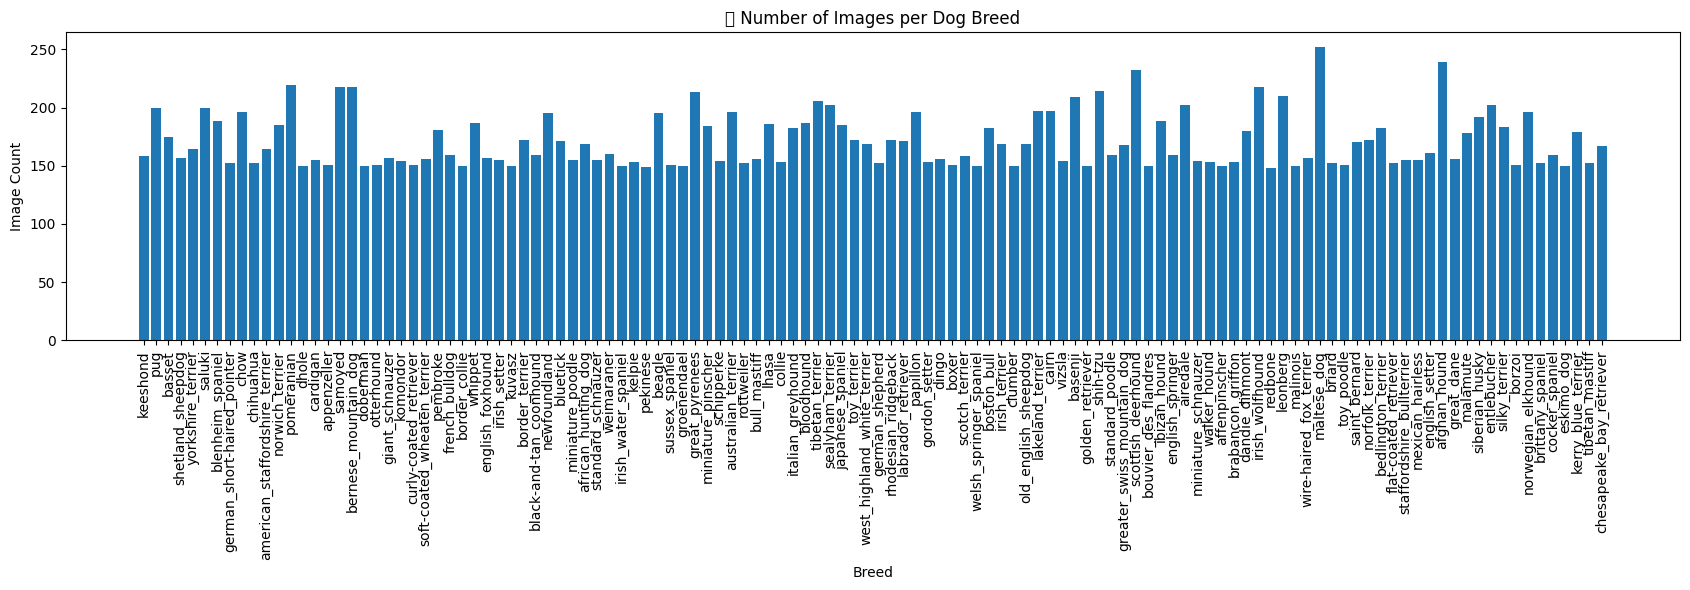

In [ ]:
#A plot to see if the data is balanced
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

image_dir = Path("archive/Images")

class_counts = Counter()
for class_folder in image_dir.iterdir():
    if class_folder.is_dir():
        raw_name = class_folder.name
        clean_name = raw_name.split("-", 1)[-1].lower()
        class_counts[clean_name] = len(list(class_folder.glob("*.jpg")))

# Plot
plt.figure(figsize=(17, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("📊 Number of Images per Dog Breed")
plt.xlabel("Breed")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

In [ ]:
#Most common dimensions of photos
from PIL import Image

image_shapes = []

for class_folder in image_dir.iterdir():
    for image_path in class_folder.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_shapes.append(img.size)  # (width, height)

# Most common dimensions
from collections import Counter
common_dims = Counter(image_shapes).most_common(10)
print("Most common image dimensions:")
for dim, count in common_dims:
    print(f"{dim}: {count} images")


Most common image dimensions:
(500, 375): 5301 images
(500, 333): 2098 images
(375, 500): 1225 images
(333, 500): 706 images
(500, 334): 356 images
(500, 332): 298 images
(334, 500): 138 images
(500, 400): 132 images
(500, 357): 117 images
(400, 300): 117 images


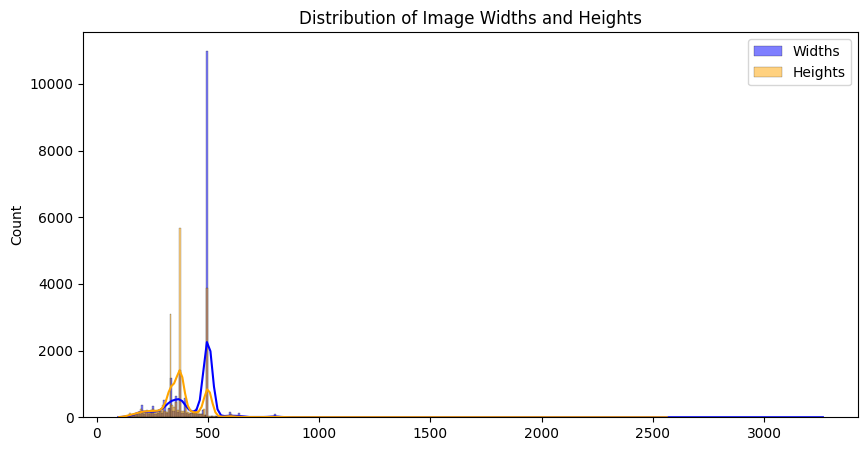

In [ ]:
#Width and Height Trend
import seaborn as sns

widths = [w for w, h in image_shapes]
heights = [h for w, h in image_shapes]

plt.figure(figsize=(10, 5))
sns.histplot(widths, color='blue', label='Widths', kde=True)
sns.histplot(heights, color='orange', label='Heights', kde=True)
plt.legend()
plt.title("Distribution of Image Widths and Heights")
plt.show()

## Parsing

In [ ]:
#Parsing
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd

annotation_dir = Path("archive/Annotation")
image_dir = Path("archive/Images")

# Add .xml extension if missing
for breed_folder in annotation_dir.iterdir():
    if breed_folder.is_dir():
        for file in breed_folder.iterdir():
            if file.is_file() and file.suffix == '':
                file.rename(file.with_name(file.name + ".xml"))

# Build WordNet ID to folder name map
folder_map = {
    folder.name.lower().split("-")[0]: folder.name
    for folder in image_dir.iterdir()
    if folder.is_dir()
}

records = []

# Parse XML and collect records
for xml_file in annotation_dir.rglob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename_tag = root.find("filename")
    if filename_tag is not None and filename_tag.text.strip() == "%s":
            filename_tag.text = xml_file.stem + ".jpg"
            tree.write(xml_file)

    filename = filename_tag.text
    wordnet_id = filename.split("_")[0].lower()

    folder_name = folder_map.get(wordnet_id)
    if folder_name is None:
        print(f"No folder found for ID: {wordnet_id}")
        continue

    if not filename.lower().endswith(".jpg"):
      filename += ".jpg"

    image_path = image_dir / folder_name / filename

    # Remove WordNet ID and keep underscores
    breed_clean = folder_name[len(wordnet_id)+1:]

    records.append((str(image_path), breed_clean))

# Create DataFrame
df = pd.DataFrame(records, columns=["image_path", "breed"])
print(f"Records collected: {len(records)}")
df.head()


Records collected: 20580


,image_path,breed
0,archive/Images/n02112350-keeshond/n02112350_69...,keeshond
1,archive/Images/n02112350-keeshond/n02112350_10...,keeshond
2,archive/Images/n02112350-keeshond/n02112350_98...,keeshond
3,archive/Images/n02112350-keeshond/n02112350_73...,keeshond
4,archive/Images/n02112350-keeshond/n02112350_70...,keeshond


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Mapping Breeds with specified integers
breed_to_label = {breed: i for i, breed in enumerate(sorted(df["breed"].unique()))}
df["label"] = df["breed"].map(breed_to_label)

df.head()

,image_path,breed,label
0,archive/Images/n02112350-keeshond/n02112350_69...,keeshond,97
1,archive/Images/n02112350-keeshond/n02112350_10...,keeshond,97
2,archive/Images/n02112350-keeshond/n02112350_98...,keeshond,97
3,archive/Images/n02112350-keeshond/n02112350_73...,keeshond,97
4,archive/Images/n02112350-keeshond/n02112350_70...,keeshond,97


In [ ]:
#Preview
print("Breed to Label Mapping:")
for breed, label in list(breed_to_label.items())[:10]:
    print(f"{label}: {breed}")

Breed to Label Mapping:
0: Afghan_hound
1: African_hunting_dog
2: Airedale
3: American_Staffordshire_terrier
4: Appenzeller
5: Australian_terrier
6: Bedlington_terrier
7: Bernese_mountain_dog
8: Blenheim_spaniel
9: Border_collie


In [ ]:
import random

# Generate 10 random (image_path, label) pairs
random_samples = df[["image_path", "label"]].sample(10, random_state=42)

for path, label in zip(random_samples["image_path"], random_samples["label"]):
    print(f"{path} → Label: {label}")

archive/Images/n02105162-malinois/n02105162_1357.jpg → Label: 102
archive/Images/n02091635-otterhound/n02091635_2482.jpg → Label: 106
archive/Images/n02109961-Eskimo_dog/n02109961_1613.jpg → Label: 24
archive/Images/n02112137-chow/n02112137_10815.jpg → Label: 86
archive/Images/n02101388-Brittany_spaniel/n02101388_5512.jpg → Label: 14
archive/Images/n02088632-bluetick/n02088632_926.jpg → Label: 80
archive/Images/n02093859-Kerry_blue_terrier/n02093859_1645.jpg → Label: 39
archive/Images/n02108000-EntleBucher/n02108000_204.jpg → Label: 23
archive/Images/n02090622-borzoi/n02090622_906.jpg → Label: 81
archive/Images/n02097209-standard_schnauzer/n02097209_2505.jpg → Label: 114


## Preprocessing

In [ ]:
#Standard image size of resnet is around 224, 224, change if necessary

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
df["label_str"] = df["label"].astype(str)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=None
)

train_gen = datagen.flow_from_dataframe(
    dataframe=df,
    x_col="image_path",
    y_col="label_str",
    target_size=img_size,
    batch_size=32,
    class_mode="sparse",
    #subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=df,
    x_col="image_path",
    y_col="label_str",
    target_size=img_size,
    batch_size=32,
    class_mode="sparse",
    #subset="validation",
    shuffle=False
)

Found 20580 validated image filenames belonging to 120 classes.
Found 20580 validated image filenames belonging to 120 classes.


In [ ]:
print(f"📦 Total records: {len(df)}")
print(f"🐶 Total unique breeds: {df['breed'].nunique()}")

📦 Total records: 20580
🐶 Total unique breeds: 120


In [ ]:
from pathlib import Path
missing = [p for p in df["image_path"] if not Path(p).exists()]
print(f"Missing files: {len(missing)}")

Missing files: 0


## Data Load and Split

🖼️ Total images physically present: 20580
Example: [PosixPath('archive/Images/n02112350-keeshond/n02112350_2640.jpg'), PosixPath('archive/Images/n02112350-keeshond/n02112350_8177.jpg'), PosixPath('archive/Images/n02112350-keeshond/n02112350_8310.jpg')]
